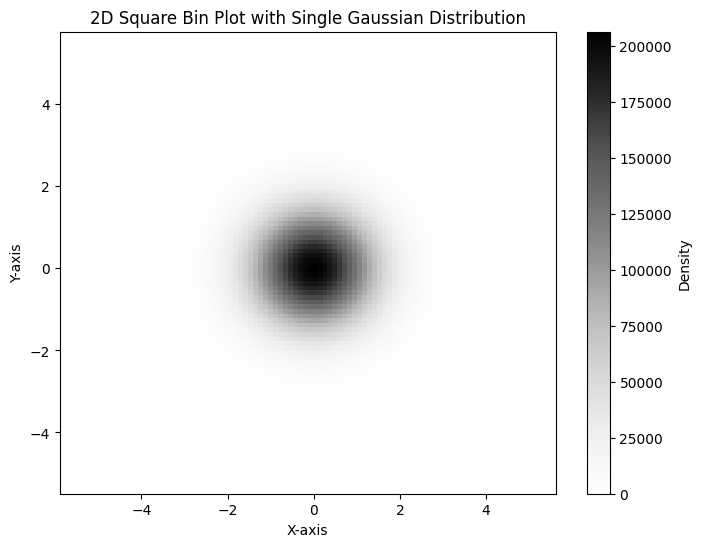

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Generate random data for a single Gaussian distribution
np.random.seed(42)
data_points = 100000000  # 100 million points
x = np.random.normal(loc=0, scale=1, size=data_points)
y = np.random.normal(loc=0, scale=1, size=data_points)

# Create a 2D square bin plot with more bins
plt.figure(figsize=(8, 6))
plt.hist2d(x, y, bins=100, cmap='Greys')

# Customize the plot
plt.colorbar(label='Density')
plt.title('2D Square Bin Plot with Single Gaussian Distribution')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.gca().set_facecolor('white')

# Show the plot
plt.show()

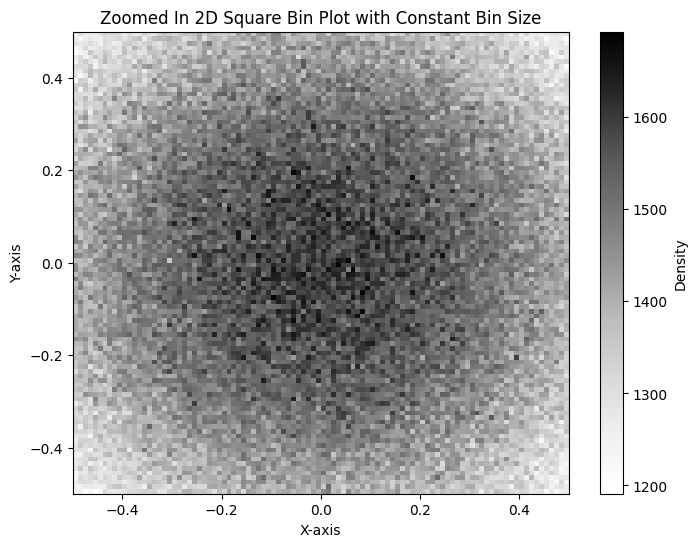

In [25]:
# Create a "zoomed in" 2D square bin plot with a smaller spatial range and constant bin size
mask = (x > -0.5) & (x < 0.5) & (y > -0.5) & (y < 0.5)
zoom_x = x[mask]
zoom_y = y[mask]

# Use the same bins as the original plot
constant_bins = 100

plt.figure(figsize=(8, 6))
plt.hist2d(zoom_x, zoom_y, bins=constant_bins, cmap='Greys')

# Customize the plot
plt.colorbar(label='Density')
plt.title('Zoomed In 2D Square Bin Plot with Constant Bin Size')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.gca().set_facecolor('white')

# Show the plot
plt.show()

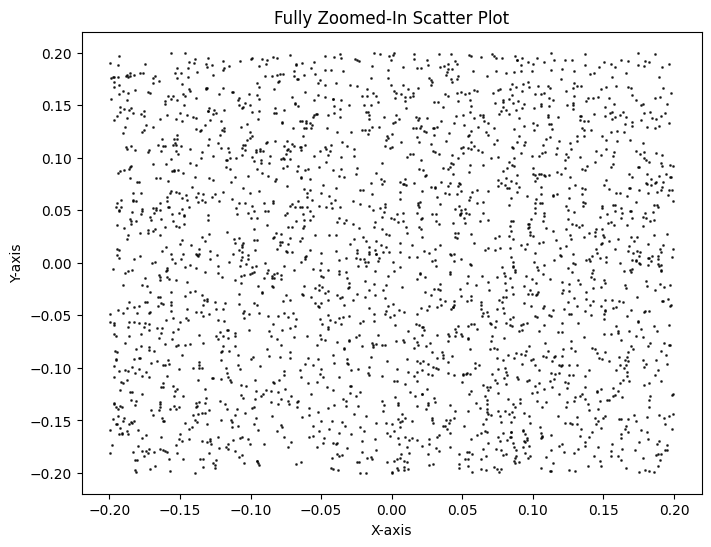

In [14]:
# Create a fully zoomed-in scatter plot with black points
mask_zoomed_in = (x > -0.2) & (x < 0.2) & (y > -0.2) & (y < 0.2)
zoomed_in_x = x[mask_zoomed_in]
zoomed_in_y = y[mask_zoomed_in]

plt.figure(figsize=(8, 6))
plt.scatter(zoomed_in_x, zoomed_in_y, color='black', s=1, alpha=0.7)

# Customize the plot
plt.title('Fully Zoomed-In Scatter Plot')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.gca().set_facecolor('white')

# Show the plot
plt.show()

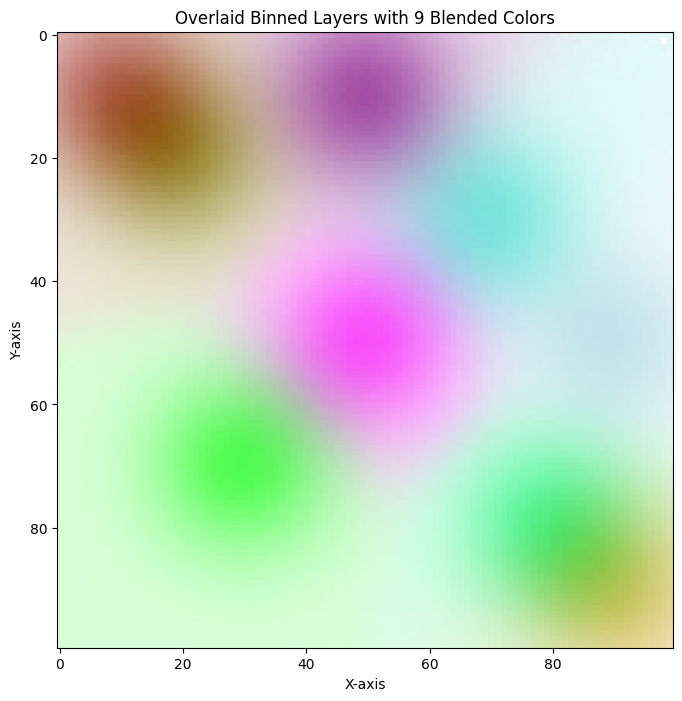

In [21]:
import datashader as ds
import datashader.transfer_functions as tf
from datashader.utils import export_image

# Generate random data for multiple Gaussian distributions
np.random.seed(42)
data_points_per_class = 10000000  # 10 million points per class

x1 = np.random.normal(loc=-2, scale=1, size=data_points_per_class)
y1 = np.random.normal(loc=-2, scale=1, size=data_points_per_class)

x2 = np.random.normal(loc=2, scale=1, size=data_points_per_class)
y2 = np.random.normal(loc=2, scale=1, size=data_points_per_class)

x3 = np.random.normal(loc=0, scale=1, size=data_points_per_class)
y3 = np.random.normal(loc=0, scale=1, size=data_points_per_class)

x4 = np.random.normal(loc=-3, scale=1, size=data_points_per_class)
y4 = np.random.normal(loc=3, scale=1, size=data_points_per_class)

x5 = np.random.normal(loc=3, scale=1, size=data_points_per_class)
y5 = np.random.normal(loc=-3, scale=1, size=data_points_per_class)

x6 = np.random.normal(loc=-4, scale=1, size=data_points_per_class)
y6 = np.random.normal(loc=4, scale=1, size=data_points_per_class)

x7 = np.random.normal(loc=4, scale=1, size=data_points_per_class)
y7 = np.random.normal(loc=-4, scale=1, size=data_points_per_class)

x8 = np.random.normal(loc=0, scale=1, size=data_points_per_class)
y8 = np.random.normal(loc=4, scale=1, size=data_points_per_class)

x9 = np.random.normal(loc=4, scale=1, size=data_points_per_class)
y9 = np.random.normal(loc=0, scale=1, size=data_points_per_class)

# Combine data into a single DataFrame
data = {
    'x': np.concatenate([x1, x2, x3, x4, x5, x6, x7, x8, x9]),
    'y': np.concatenate([y1, y2, y3, y4, y5, y6, y7, y8, y9]),
    'color': pd.Categorical(np.concatenate([
        np.full_like(x1, 'Label Class 1', dtype=object),
        np.full_like(x2, 'Label Class 2', dtype=object),
        np.full_like(x3, 'Label Class 3', dtype=object),
        np.full_like(x4, 'Label Class 4', dtype=object),
        np.full_like(x5, 'Label Class 5', dtype=object),
        np.full_like(x6, 'Label Class 6', dtype=object),
        np.full_like(x7, 'Label Class 7', dtype=object),
        np.full_like(x8, 'Label Class 8', dtype=object),
        np.full_like(x9, 'Label Class 9', dtype=object)
    ]))
}

import pandas as pd
df = pd.DataFrame(data)

# Create a canvas for datashader with 100x100 bins
canvas = ds.Canvas(plot_width=100, plot_height=100, x_range=(-5, 5), y_range=(-5, 5))

# Aggregate data by color
agg = canvas.points(df, 'x', 'y', ds.count_cat('color'))

# Define color key for 9 colors
color_key = {
    'Label Class 1': '#00FF00',  # Green
    'Label Class 2': '#40E0D0',  # Turquoise
    'Label Class 3': '#FF00FF',  # Magenta
    'Label Class 4': '#808000',  # Olive
    'Label Class 5': '#00FF80',  # Spring Green
    'Label Class 6': '#A52A2A',  # Brown
    'Label Class 7': '#DAA520',  # Goldenrod
    'Label Class 8': '#800080',  # Purple
    'Label Class 9': '#ADD8E6'   # Light Blue
}

# Create a blended image
img = tf.shade(agg, color_key=color_key, how='linear')

# Display the image using matplotlib
plt.figure(figsize=(8, 8))
plt.imshow(img.to_pil(), origin='upper')
plt.title('Overlaid Binned Layers with 9 Blended Colors')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.show()

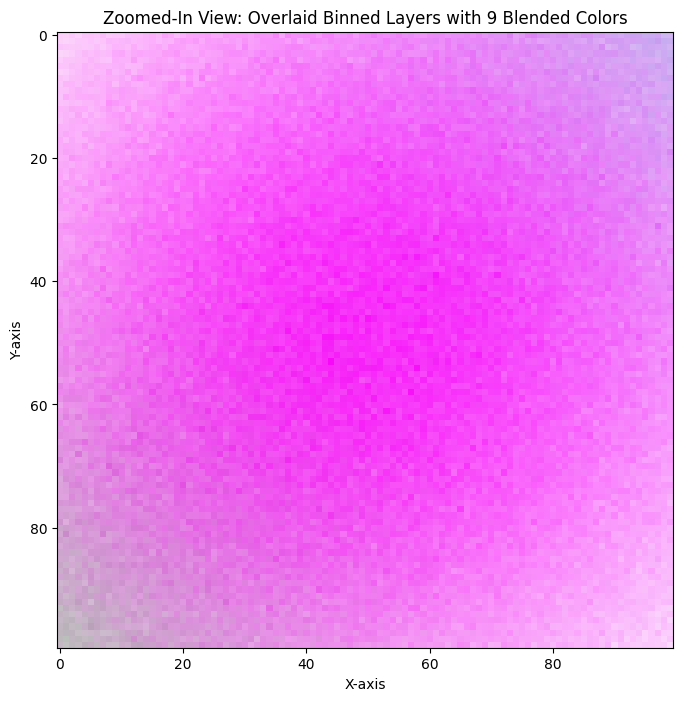

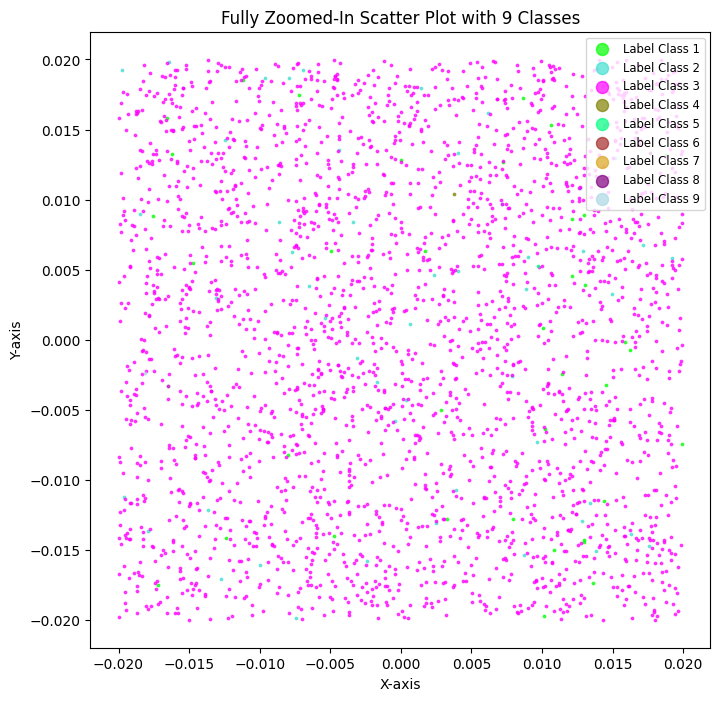

In [29]:
# Create a zoomed-in view for the color plot
zoom_canvas = ds.Canvas(plot_width=100, plot_height=100, x_range=(-1, 1), y_range=(-1, 1))
zoom_agg = zoom_canvas.points(df, 'x', 'y', ds.count_cat('color'))
zoom_img = tf.shade(zoom_agg, color_key=color_key, how='linear')

# Display the zoomed-in image using matplotlib
plt.figure(figsize=(8, 8))
plt.imshow(zoom_img.to_pil(), origin='upper')
plt.title('Zoomed-In View: Overlaid Binned Layers with 9 Blended Colors')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.show()

# Create a fully zoomed-in scatter plot with black points for the color plot
mask_fully_zoomed_in = (df['x'] > -0.02) & (df['x'] < 0.02) & (df['y'] > -0.02) & (df['y'] < 0.02)
fully_zoomed_in_df = df[mask_fully_zoomed_in]

plt.figure(figsize=(8, 8))
for label, color in color_key.items():
    subset = fully_zoomed_in_df[fully_zoomed_in_df['color'] == label]
    plt.scatter(subset['x'], subset['y'], color=color, s=3, label=label, alpha=0.7)

# Customize the plot
plt.title('Fully Zoomed-In Scatter Plot with 9 Classes')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend(loc='upper right', markerscale=5, fontsize='small')
plt.gca().set_facecolor('white')

# Show the plot
plt.show()